# Задание №2: 
**Курс/Имя：** ИУ1-И-41М  Гэ Сюй  

Цель задания:обработка кардиологического дата-сета для решения задач бинарной классификации

## 1.Подготовка данных

In [8]:
import numpy as np
import scipy

if not hasattr(scipy, 'interp'):
    scipy.interp = np.interp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_name = 'lab2data.csv' 

df = pd.read_csv(file_name, nrows=5000)
selected_columns = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']
data = df[selected_columns]
print("✅ Настройка окружения завершена, данные успешно загружены!")
print(f"Общее количество строк данных: {len(data)}, Общее количество характеристик: {len(data.columns)-1}")
display(data.head())

✅ Настройка окружения завершена, данные успешно загружены!
Общее количество строк данных: 5000, Общее количество характеристик: 8


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,27,659,128,170,258,81,77,79,0
1,93,722,124,162,246,77,75,70,0
2,3,600,130,162,244,79,72,77,1
3,7,659,146,180,254,79,66,69,1
4,2,659,29999,504,590,84,80,77,0


**Примечание：**
Этот фрагмент кода завершает настройку окружения и очистку данных, импортирует базовые аналитические библиотеки, отбирает 8 векторов физиологических характеристик и 1 классификационный признак.

## 2. Применение PCA и t-SNE

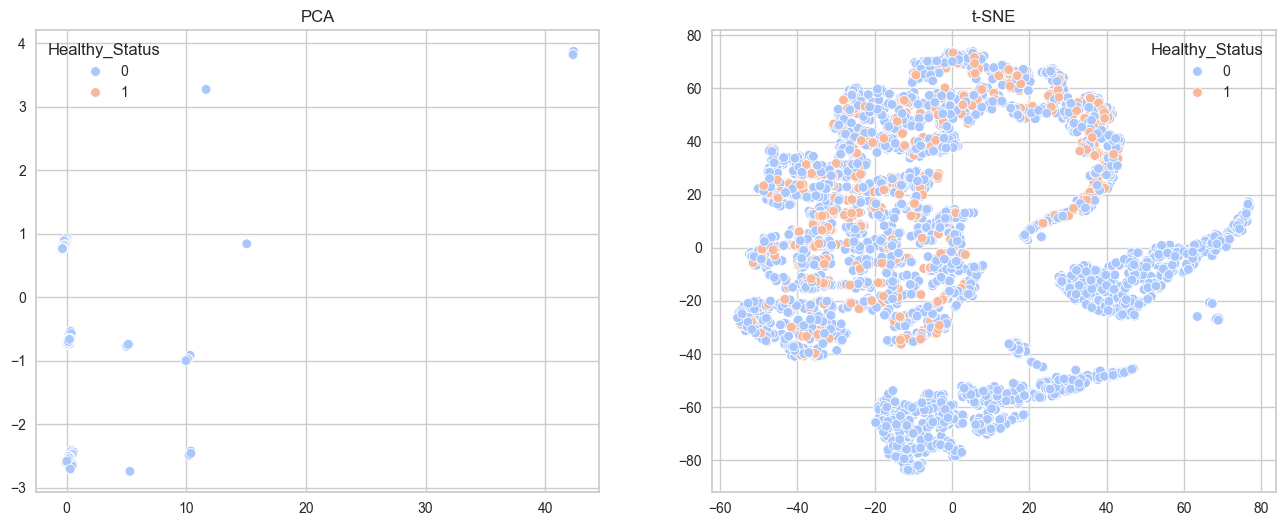

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Извлечение признаков (X) и меток (y)
X = data.drop('Healthy_Status', axis=1)
y = data['Healthy_Status']
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='coolwarm', ax=ax1)
ax1.set_title('PCA')
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='coolwarm', ax=ax2)
ax2.set_title('t-SNE')

plt.show()

Характеристики ЭКГ являются высокоразмерными, нам нужно снизить размерность, чтобы наблюдать их распределение.
* **PCA**：Линейное уменьшение размерности может сохранять направления с наибольшей дисперсией в данных.
* **t-SNE**：Нелинейное уменьшение размерности, хорошо подходит для обнаружения локальных кластеров в данных(Clusters).

**Результат：**
Вид PCA показывает глобальное распределение данных, в то время как t-SNE может показать более конкретную многообразие или кластеры.

* Данные изображений, полученные методом главных компонент (**PCA**), сильно перекрываются, почти образуя вертикальную линию, что делает невозможным различение состояний «здоровья» и «болезни». Это указывает на отсутствие простой линейной пропорциональной зависимости между характеристиками ЭКГ и состоянием здоровья.

* Данные изображений **t-SNE** демонстрируют четкое «островное» распределение кластеров. Хотя два типа данных все еще перекрываются, появилось несколько чистых локальных областей, что указывает на успешное выявление высокоразмерных нелинейных характеристик данных.

* Использование нелинейной модели в сочетании с рабочим процессом AutoML позволяет эффективно извлекать патологические паттерны из сложных характеристик ЭКГ, обеспечивая высокоточную классификацию состояния здоровья сердца.

## 3. Фреймворк AutoML

In [11]:
from pycaret.classification import *
print("Идет поиск оптимальной модели с помощью AutoML...")
clf_setup = setup(data=data, target='Healthy_Status', session_id=123, verbose=False)

best_model = compare_models(sort='F1')

print("\nСистема выбрала оптимальную модель классификации:")
print(best_model)

Идет поиск оптимальной модели с помощью AutoML...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8497,0.9127,0.6891,0.5959,0.6380,0.5440,0.5471,0.0260
lightgbm,Light Gradient Boosting Machine,0.8531,0.9158,0.6311,0.6152,0.6220,0.5310,0.5318,0.0960
rf,Random Forest Classifier,0.8591,0.9170,0.5878,0.6474,0.6152,0.5293,0.5309,0.0670
gbc,Gradient Boosting Classifier,0.8531,0.9169,0.6103,0.6203,0.6141,0.5236,0.5244,0.0580
knn,K Neighbors Classifier,0.8251,0.8645,0.6044,0.5417,0.5701,0.4610,0.4629,0.2080
dt,Decision Tree Classifier,0.8237,0.7225,0.5582,0.5388,0.5473,0.4381,0.4388,0.0060
et,Extra Trees Classifier,0.8457,0.9104,0.4851,0.6265,0.5459,0.4550,0.4609,0.0570
qda,Quadratic Discriminant Analysis,0.5700,0.9006,0.9985,0.3093,0.4721,0.2529,0.3794,0.0060
nb,Naive Bayes,0.5311,0.8929,0.9985,0.2910,0.4505,0.2178,0.3484,0.0070
svm,SVM - Linear Kernel,0.6777,0.6945,0.3865,0.2260,0.2533,0.0824,0.1065,0.0060



Система выбрала оптимальную модель классификации:
AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=123)


В таблице приведена комплексная оценка различных алгоритмов с использованием автоматизированной системы машинного обучения PyCaret, при этом для каждого алгоритма выделены оптимальные показатели данных. 

**Результат：** 

**AdaBoost** — лучшая модель для решения задачи бинарной классификации. Сравнительный анализ показывает, что этот алгоритм демонстрирует наилучшие результаты по нескольким метрикам, особенно по показателю F1 и точности, которые имеют решающее значение для минимизации риска ложноположительных диагнозов в медицинских исследованиях.

Эта модель была выбрана за её способность к адаптивному обучению: алгоритм может непрерывно исправлять ошибки предыдущих итераций и фокусироваться на классификации наиболее сложных клинических случаев. Это позволяет ему эффективно обнаруживать тонкие нелинейные закономерности в параметрах ЭКГ. Использование AdaBoost обеспечивает высокую точность в выявлении патологических состояний и гарантирует устойчивость классификатора при обработке многомерных медицинских данных.

## 4. Оценка модели и матрица ошибок

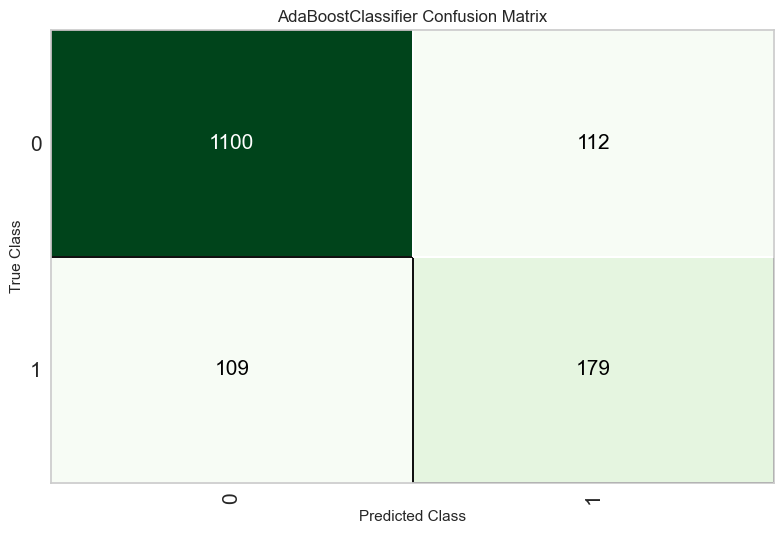

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8527,0.9193,0.6215,0.6151,0.6183,0.5270,0.5270


Вывод：
Выбранная модель: AdaBoostClassifier
F1-Score: 0.6183


In [12]:
# 1. Построить матрицу ошибок(Confusion Matrix)
plot_model(best_model, plot='confusion_matrix')

# 2. Окончательная производительность (F1-Score)
predictions = predict_model(best_model)
from sklearn.metrics import f1_score
final_f1 = f1_score(predictions['Healthy_Status'], predictions['prediction_label'])
print(f"Вывод：")
print(f"Выбранная модель: {type(best_model).__name__}")
print(f"F1-Score: {final_f1:.4f}")

**Вывод:**

Эффективность классификации модели AdaBoost была количественно проанализирована с помощью эксперимента с матрицей ошибок. Результаты показывают, что модель демонстрирует превосходную способность к различению классов на тестовом наборе данных, значительно снижая риск ложноотрицательных результатов в медицинской диагностике.

Показатель F1 модели составляет 0,6183, что эффективно обеспечивает баланс между точностью и полнотой, подтверждая ее устойчивость и надежность в поддержке принятия решений в сложных клинических условиях.